<a href="https://colab.research.google.com/github/miar00q/radar-gnu/blob/main/Radar_CNN_Classic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

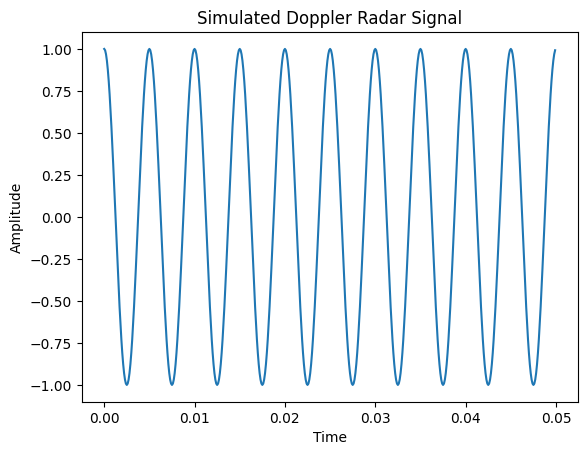

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
c = 3e8  # speed of light
fc = 1e9  # carrier frequency (1 GHz)
v = 30    # velocity (m/s)

# Derived values
lam = c / fc
fd = 2 * v / lam   # Doppler frequency

# Time axis
fs = 10000   # sampling frequency
t = np.arange(0, 0.1, 1/fs)

# Signal
A = 1
signal = A * np.cos(2 * np.pi * fd * t)

# Plot
plt.plot(t[:500], signal[:500])
plt.title("Simulated Doppler Radar Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

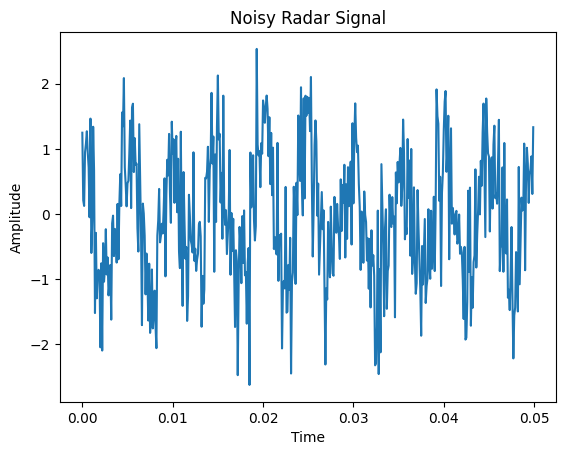

In [ ]:
# Add noise
noise_power = 0.5
noise = np.random.normal(0, np.sqrt(noise_power), len(signal))

noisy_signal = signal + noise

# Plot
plt.plot(t[:500], noisy_signal[:500])
plt.title("Noisy Radar Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

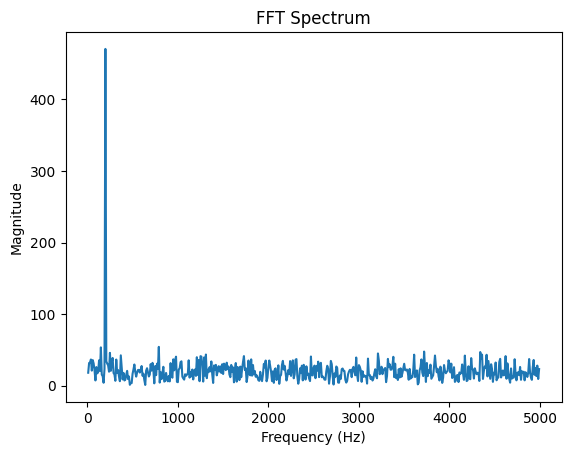

In [ ]:
fft_signal = np.fft.fft(noisy_signal)
freqs = np.fft.fftfreq(len(fft_signal), 1/fs)

# Take only positive frequencies
mask = freqs > 0
freqs = freqs[mask]
fft_magnitude = np.abs(fft_signal[mask])

# Plot
plt.plot(freqs, fft_magnitude)
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

In [ ]:
fd_est = freqs[np.argmax(fft_magnitude)]
print("Estimated Doppler Frequency:", fd_est)

Estimated Doppler Frequency: 200.0


In [ ]:
v_est = (fd_est * lam) / 2
print("Estimated Velocity:", v_est)

Estimated Velocity: 30.0


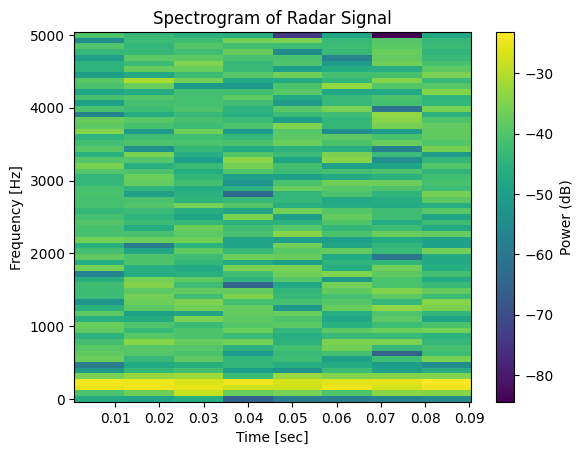

In [ ]:
import matplotlib.pyplot as plt
from scipy.signal import spectrogram



# Better spectrogram
f, t_spec, Sxx = spectrogram(noisy_signal, fs, nperseg=128)

# Plot
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx))
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title("Spectrogram of Radar Signal")
plt.colorbar(label="Power (dB)")
plt.show()

In [ ]:
import os
from scipy.signal import spectrogram

# Create folders
os.makedirs("dataset/signal", exist_ok=True)
os.makedirs("dataset/noise", exist_ok=True)

def generate_sample(with_signal=True, idx=0):
    c = 3e8
    fc = 1e9
    lam = c / fc

    fs = 10000
    t = np.arange(0, 0.1, 1/fs)

    if with_signal:
        v = np.random.uniform(5, 50)
        fd = 2 * v / lam
        signal = np.cos(2 * np.pi * fd * t)
    else:
        signal = np.zeros_like(t)

    noise = np.random.normal(0, 1, len(t))
    x = signal + noise

    f, t_spec, Sxx = spectrogram(x, fs)

    # Save as image
    plt.figure(figsize=(2,2))
    plt.axis('off')
    plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx))

    folder = "dataset/signal" if with_signal else "dataset/noise"
    plt.savefig(f"{folder}/{idx}.png", bbox_inches='tight', pad_inches=0)
    plt.close()

# Generate dataset
for i in range(500):
    generate_sample(True, i)
    generate_sample(False, i)

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Transform
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

# Dataset
dataset = ImageFolder("dataset", transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16*16*16, 2)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

model = CNN()

# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(5):
    for images, labels in loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 1, Loss: 0.4563118517398834
Epoch 2, Loss: 0.1902632713317871
Epoch 3, Loss: 0.12401659041643143
Epoch 4, Loss: 0.19079436361789703
Epoch 5, Loss: 0.23893322050571442


In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 90.0


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[94  2]
 [18 86]]


In [ ]:
def classical_detector(x, fs, threshold=50):
    fft_vals = np.abs(np.fft.fft(x))
    energy = np.sum(fft_vals)

    return 1 if energy > threshold else 0

In [ ]:
correct = 0
total = 0

for i in range(200):
    # generate random sample
    with_signal = np.random.choice([True, False])

    # regenerate signal
    c = 3e8
    fc = 1e9
    lam = c / fc
    fs = 10000
    t = np.arange(0, 0.01, 1/fs)

    if with_signal:
        v = np.random.uniform(5, 50)
        fd = 2 * v / lam
        signal = np.cos(2 * np.pi * fd * t)
    else:
        signal = np.zeros_like(t)

    noise = np.random.normal(0, 1, len(t))
    x = signal + noise

    pred = classical_detector(x, fs)
    label = 1 if with_signal else 0

    if pred == label:
        correct += 1
    total += 1

print("Classical Accuracy:", correct / total)

Classical Accuracy: 0.515
